
# The Transformer & Self-Attention

*A lecture note on how every position in a sequence can attend to every
other position at once — and why that idea replaced recurrence almost
everywhere in modern NLP.*

---

## 1. Intro: the problem this solves

The `rnn-lstm-language-modeling` tutorial in this domain builds language
models that read a sentence **one token at a time**, carrying a hidden
state forward — word 2 can't be processed until word 1 is done, word 3
can't be processed until word 2 is done, and so on. That's an inherent
**sequential bottleneck**: even with a GPU that could in principle do
hundreds of matrix multiplies simultaneously, an RNN forces them into a
strict chain. It also means information from token 1 has to survive being
squeezed through the hidden state across every intermediate step before it
can influence token 50 — which is exactly why LSTMs needed gates to fight
vanishing gradients over long sequences.

The `seq2seq-attention-machine-translation` tutorial in this domain already
introduced a fix for *part* of that problem: instead of forcing the entire
source sentence through one fixed-size hidden vector, let the decoder look
back at *all* of the encoder's hidden states and learn which ones matter
for the word it's generating right now. That's **attention** — but in that
tutorial it's *cross*-attention: one sequence (the decoder) attending to a
*different* sequence (the encoder). The encoder itself is still an RNN,
still reading the source sentence one token at a time, still sequential.

**The Transformer**, introduced by Vaswani et al. (2017) in the aptly
titled paper *"Attention Is All You Need,"* asks a more radical question:
what if we used that same attention idea *inside* a single sequence — let
every token attend to every other token in the *same* sentence — and threw
the recurrence away entirely? That's **self-attention**, and because it has
no token-to-token chain of dependency, every position's attention output
can be computed **in parallel**, on a GPU, in one shot. This tutorial
derives self-attention and multi-head attention from scratch, implements
them in PyTorch, and then inspects the real attention weights inside a
pretrained BERT-family model to see what it actually learned to look at.

**By the end you'll be able to:**
- Explain, in plain language, what self-attention computes and why it's
  parallel instead of sequential.
- Derive scaled dot-product attention and multi-head attention precisely,
  including *why* the $1/\sqrt{d_k}$ scaling term is mathematically
  necessary.
- Explain why self-attention has no built-in sense of word order, and how
  positional encoding fixes that.
- Implement multi-head self-attention from scratch in PyTorch and run it
  on real word embeddings.
- Load a real pretrained Transformer (DistilBERT) and visualize its actual
  attention weights on a linguistically interesting sentence.



## 2. The idea, intuitively

Imagine you're reading the sentence:

> "The trophy doesn't fit in the suitcase because **it** is too big."

To understand what "it" refers to, you don't re-read the sentence
left-to-right accumulating a fuzzy summary. You instantly **look back** at
every other word in the sentence and weigh how relevant each one is to
resolving "it" — "trophy" is highly relevant, "suitcase" is also a
candidate, "because" and "the" are basically irrelevant. You do this for
*every* word in the sentence simultaneously, not one at a time.

That's exactly what **self-attention** does, mechanically:

- Every token produces a **Query** ("what am I looking for?"), a **Key**
  ("what do I contain, for others to match against?"), and a **Value**
  ("what information do I actually offer if picked").
- Every token's Query is compared against *every* token's Key (including
  its own) to produce a relevance score.
- Those scores are turned into weights (via softmax) and used to compute a
  weighted average of every token's Value.
- The result: each token's new representation is a blend of every other
  token's information, weighted by how relevant they are *to it*.

Crucially, none of this requires knowing the *order* in which we process
the comparisons — token 5's attention computation doesn't need token 4's
result first. All $n$ tokens' attention outputs can be computed
**simultaneously** as a handful of matrix multiplications. That's the
whole point: same underlying idea as the seq2seq tutorial's
encoder-attends-to-decoder mechanism, just applied *within* one sequence
and computed in parallel rather than one step at a time.

Here's the mechanism in miniature — no learned weights yet, just three toy
3-dimensional "embeddings" and raw dot-product similarity, so you can see
the shape of the computation before any of the theory:


In [1]:

import numpy as np

# Three toy "tokens", each already represented as a 3-dim vector.
# (In a real model these come from an embedding layer; here we just
# hand-pick them so the similarity structure is obvious.)
tokens = ["cat", "sat", "mat"]
X = np.array([
    [1.0, 0.1, 0.0],   # "cat"
    [0.9, 0.0, 0.2],   # "sat"  (similar direction to "cat" and "mat")
    [1.0, 0.0, 0.1],   # "mat"
])

# Toy "attention": how similar is every token to every other token?
scores = X @ X.T                                  # raw dot-product similarity
weights = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)  # softmax per row

print("Similarity scores (rows = query token, cols = key token):")
print(np.round(scores, 2))
print("\nAttention weights after softmax (each row sums to 1):")
print(np.round(weights, 2))
print("\nEach row says: when this token asks a question, how much should it")
print("listen to every other token's value? We'll formalize Q, K, V next.")


Similarity scores (rows = query token, cols = key token):
[[1.01 0.9  1.  ]
 [0.9  0.85 0.92]
 [1.   0.92 1.01]]

Attention weights after softmax (each row sums to 1):
[[0.35 0.31 0.34]
 [0.34 0.32 0.34]
 [0.34 0.31 0.34]]

Each row says: when this token asks a question, how much should it
listen to every other token's value? We'll formalize Q, K, V next.



That's the whole shape of self-attention: a similarity matrix between
every pair of positions, turned into per-row weights, used to mix
information. The rest of this tutorial is about making that precise —
learned Query/Key/Value projections instead of raw embeddings, a scaling
factor that keeps the softmax well-behaved, running several of these in
parallel ("heads"), and injecting position information since this
mechanism, as built so far, cannot tell "cat sat mat" from "mat sat cat."

> **Takeaway:** self-attention lets every token look directly at every
> other token in one parallel step, instead of forcing information through
> a sequential chain of hidden states like an RNN does.



## 3. Going deeper: the formal definition

*(This is the rigor section. If you're happy with the intuition above, you
can skim this and come back later — but the implementation section reuses
this exact notation.)*

### 3.1 Scaled dot-product attention

Let $X \in \mathbb{R}^{n \times d_{\text{model}}}$ be a sequence of $n$
token embeddings, each of dimension $d_{\text{model}}$ (row $i$ is token
$i$'s embedding, possibly already including positional information — see
§3.4). We learn three weight matrices $W^Q, W^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$
and $W^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$, and project:

$$Q = XW^Q \qquad K = XW^K \qquad V = XW^V$$

- $Q \in \mathbb{R}^{n \times d_k}$ — the **Query** matrix: row $i$ is "what
  token $i$ is looking for."
- $K \in \mathbb{R}^{n \times d_k}$ — the **Key** matrix: row $j$ is "what
  token $j$ advertises about itself, to be matched against."
- $V \in \mathbb{R}^{n \times d_v}$ — the **Value** matrix: row $j$ is "what
  token $j$ actually contributes" if it's attended to.

$Q$, $K$, and $V$ are each just a *learned linear projection of the same
input embeddings* $X$ — three different linear lenses on the same tokens,
not three different inputs. Attention is then defined as:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Reading it left to right:

1. $QK^\top \in \mathbb{R}^{n \times n}$: every query dotted with every
   key — entry $(i, j)$ is "how relevant is token $j$'s key to token $i$'s
   query." This is the $n \times n$ pairwise relevance matrix.
2. Divide every entry by $\sqrt{d_k}$ — the scaling term, justified below.
3. $\text{softmax}(\cdot)$ row-wise turns each row into a probability
   distribution over the $n$ tokens (weights that sum to 1) — how much
   token $i$ should attend to each token $j$.
4. Multiply by $V$: for each token $i$, take the weighted average of every
   token's Value vector, weighted by the attention distribution from step 3.

The output is again $n \times d_v$: one new vector per input token, each a
context-mixed blend of the whole sequence.

### 3.2 Why divide by $\sqrt{d_k}$?

Assume the entries of $Q$ and $K$ are roughly independent with mean 0 and
variance 1 (a reasonable approximation right after initialization). Each
entry of $QK^\top$ is a dot product of two length-$d_k$ vectors:

$$q \cdot k = \sum_{i=1}^{d_k} q_i k_i$$

This is a sum of $d_k$ roughly-independent, zero-mean terms, so its
variance is $\text{Var}(q \cdot k) \approx d_k \cdot \text{Var}(q_i k_i) \approx d_k$
(variance grows *linearly with $d_k$*, so its standard deviation grows with
$\sqrt{d_k}$). As $d_k$ gets larger (real Transformers commonly use
$d_k = 64$ or more per head), the raw dot products get large in magnitude
purely from dimensionality, *not* because the tokens are more related.
Dividing by $\sqrt{d_k}$ rescales the dot products back down to
approximately unit variance, canceling that growth exactly.

Why does this matter? Because softmax is extremely sensitive to the scale
of its inputs. When the inputs to softmax are large in magnitude, softmax
saturates — one entry goes to ≈1 and the rest go to ≈0 — and the *gradient*
of softmax with respect to its inputs vanishes almost everywhere except
right at that spike. A model whose attention scores are already saturated
can't learn to adjust *which* tokens it attends to, because the gradient
signal that would tell it to shift attention elsewhere is essentially zero.
The cell below makes this concrete with real numbers.


In [2]:

import numpy as np

rng = np.random.default_rng(0)

def softmax(x):
    x = x - x.max()
    e = np.exp(x)
    return e / e.sum()

d_k = 64
n_trials = 2000

# Simulate many random query/key vectors and look at the *unscaled* vs
# *scaled* dot product distribution and the resulting softmax behavior.
raw_dots, scaled_dots = [], []
raw_max_probs, scaled_max_probs = [], []

for _ in range(n_trials):
    q = rng.normal(size=d_k)
    keys = rng.normal(size=(5, d_k))   # this query vs. 5 candidate keys
    dots = keys @ q
    raw_dots.append(dots.std())
    scaled = dots / np.sqrt(d_k)
    scaled_dots.append(scaled.std())
    raw_max_probs.append(softmax(dots).max())
    scaled_max_probs.append(softmax(scaled).max())

print(f"d_k = {d_k}")
print(f"Std of raw dot products:     {np.mean(raw_dots):6.2f}  (theory: sqrt(d_k) = {np.sqrt(d_k):.2f})")
print(f"Std of scaled dot products:  {np.mean(scaled_dots):6.2f}  (theory: ~1.0)")
print()
print(f"Mean softmax max-weight, UNSCALED dot products: {np.mean(raw_max_probs):.3f}"
      f"  (close to 1.0 = saturated / near one-hot)")
print(f"Mean softmax max-weight, SCALED dot products:   {np.mean(scaled_max_probs):.3f}"
      f"  (spread across candidates = usable gradient)")


d_k = 64
Std of raw dot products:       6.68  (theory: sqrt(d_k) = 8.00)
Std of scaled dot products:    0.83  (theory: ~1.0)

Mean softmax max-weight, UNSCALED dot products: 0.902  (close to 1.0 = saturated / near one-hot)
Mean softmax max-weight, SCALED dot products:   0.461  (spread across candidates = usable gradient)



With $d_k = 64$, the unscaled dot products have a standard deviation
around 8 (matching the $\sqrt{64}=8$ prediction), which is large enough
that softmax collapses almost all its probability mass onto a single key
essentially at random — the mean max-weight is close to 1.0 even though
the keys are pure noise with no real signal to prefer one over another.
After dividing by $\sqrt{d_k}$, the scaled dot products have unit standard
deviation and softmax stays much more spread out, leaving room for the
*learned* signal in $Q$ and $K$ (once trained) to actually move probability
mass around instead of an accident of scale doing it for free. This is
exactly why the formula has a $\sqrt{d_k}$ in the denominator and not, say,
$d_k$ or nothing at all.

### 3.3 Multi-head attention

A single attention computation forces the model to squeeze every kind of
relationship — syntactic agreement, coreference, adjacency, semantic
similarity — through one shared $d_k$-dimensional projection. **Multi-head
attention** instead runs $h$ independent attention computations in
parallel, each with its own learned projections, on smaller
$d_k = d_{\text{model}} / h$ dimensional subspaces, then concatenates and
projects the results back to $d_{\text{model}}$:

$$\text{head}_i = \text{Attention}(XW_i^Q, XW_i^K, XW_i^V), \quad i = 1, \dots, h$$

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,W^O$$

where $W_i^Q, W_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$,
$W_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$ are *separate, learned*
per-head projections, and $W^O \in \mathbb{R}^{h d_v \times d_{\text{model}}}$
is a learned output projection that mixes the concatenated heads back
together. Each head gets its own independently-learned $W^Q, W^K, W^V$, so
nothing forces two heads to learn the same notion of "relevant" — in
practice, once trained, different heads specialize: empirically, some
heads in trained Transformers learn near-diagonal (local/adjacent-token)
patterns, some learn syntactic dependencies (e.g. verb ↔ its subject), and
some learn longer-range patterns like coreference (e.g. pronoun ↔
antecedent) — the model isn't told to do this, it falls out of training
because having several independent "views" of the sequence is a strictly
more expressive hypothesis space than one shared view. We'll look at what
several real trained heads in DistilBERT actually attend to in §5.2.

### 3.4 Positional encoding: why self-attention needs it at all

Look again at $\text{softmax}(QK^\top/\sqrt{d_k})V$: nothing in that
formula refers to *where* a token is in the sequence — only to pairwise
content similarity. If you permute the rows of $X$ (i.e. shuffle the
token order) and recompute, every row of the output gets shuffled by
exactly the same permutation, but each output row's *value* is
unchanged — self-attention is a **set operation** over positions, not a
sequence operation. Concretely, self-attention alone cannot distinguish
"the dog bit the man" from "the man bit the dog," because both are the
*same set* of token embeddings in a different order, and self-attention
only looks at pairwise content similarity, never position. We verify this
concretely in §4.

The fix: before the first attention layer, add a **positional encoding**
vector to every token embedding, so position becomes part of the content
self-attention compares against. The original Transformer paper uses fixed
sinusoids of different frequencies:

$$PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
\qquad
PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

where $pos$ is the token's position in the sequence ($0, 1, 2, \dots$) and
$i$ indexes the embedding dimension pair. Intuitively:

- Each dimension pair $(2i, 2i{+}1)$ oscillates at its own frequency —
  early dimensions ($i$ small) oscillate fast (period close to $2\pi$),
  later dimensions oscillate slowly (period up to $2\pi \cdot 10000$).
- This is analogous to a clock with hands moving at different speeds: the
  second hand alone can't tell you the hour, but second + minute + hour
  hands together uniquely (and smoothly) encode a much longer span of
  time. Many frequencies together let the encoding be unique across long
  sequences while still varying *smoothly* as position increases by 1.
- Because sine and cosine are simple periodic functions, $PE_{pos+k}$ can
  be written as a fixed linear transformation of $PE_{pos}$ for any fixed
  offset $k$ — meaning the *relative* distance between two positions is
  something a linear layer can in principle recover directly from the
  encoding, not just absolute position.

Modern models increasingly replace this fixed formula with **learned**
positional embeddings (BERT does this) or with **relative** position
schemes baked directly into the attention computation, like **RoPE**
(Rotary Position Embedding, Su et al. 2021), used in most current
open-weight LLMs — see §7 for more on this still-evolving design space.



## 4. Visuals: self-attention is permutation-equivariant, and positional encoding breaks that

Before building the full multi-head implementation, let's *see* the claim
from §3.4: permute the input tokens, and self-attention's outputs are
permuted the *same* way, with the *same* values — until we add positional
encoding, at which point that symmetry breaks.


In [3]:

import numpy as np
import matplotlib.pyplot as plt

d_model = 8
n = 5
rng_data = np.random.default_rng(1)
X = rng_data.normal(size=(n, d_model))          # 5 toy token embeddings
perm = [2, 0, 4, 1, 3]                          # a fixed shuffle of the 5 positions

def simple_self_attention(X, seed=1):
    # Minimal single-head self-attention with fixed (untrained) projections,
    # reused for this permutation demo. Same seed -> same projections, so the
    # ONLY thing that differs between calls is the input ordering.
    rng_w = np.random.default_rng(seed)
    Wq, Wk, Wv = (rng_w.normal(size=(d_model, d_model)) * 0.3 for _ in range(3))
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    scores = (Q @ K.T) / np.sqrt(d_model)
    weights = np.exp(scores - scores.max(1, keepdims=True))
    weights /= weights.sum(1, keepdims=True)
    return weights @ V

def sinusoidal_pe(n, d_model):
    pos = np.arange(n)[:, None]
    i = np.arange(d_model)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((n, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return pe

out_original = simple_self_attention(X)
out_permuted = simple_self_attention(X[perm])

PE = sinusoidal_pe(n, d_model)
# IMPORTANT: add PE *after* permuting, using the fixed slot positions 0..n-1 —
# this is what a real model does: whichever word physically sits in slot q
# gets slot q's positional encoding, regardless of which word it is. So the
# permuted word "moves into" a different (word, position) pairing than it
# had originally, which is exactly what should break the symmetry below.
X_pos_original = X + PE
X_pos_permuted = X[perm] + PE
out_pos_original = simple_self_attention(X_pos_original)
out_pos_permuted = simple_self_attention(X_pos_permuted)

# Without positional encoding: permuting the input then un-permuting the
# output should recover the ORIGINAL output almost exactly.
undo = np.argsort(perm)
diff_no_pe = np.abs(out_original - out_permuted[undo]).max()
diff_with_pe = np.abs(out_pos_original - out_pos_permuted[undo]).max()

print(f"Max abs difference (no positional encoding), original vs un-permuted-output: {diff_no_pe:.2e}")
print(f"Max abs difference (with positional encoding), original vs un-permuted-output: {diff_with_pe:.2e}")
print()
print("Without PE, un-permuting the output exactly recovers the original —")
print("self-attention only reorders, it never changes the VALUES. With PE added,")
print("that no longer holds: each word now carries a DIFFERENT positional signal")
print("depending on which slot it lands in, so undoing the permutation on the")
print("output no longer recovers the original — position is now baked into content.")


Max abs difference (no positional encoding), original vs un-permuted-output: 2.78e-16
Max abs difference (with positional encoding), original vs un-permuted-output: 4.63e-01

Without PE, un-permuting the output exactly recovers the original —
self-attention only reorders, it never changes the VALUES. With PE added,
that no longer holds: each word now carries a DIFFERENT positional signal
depending on which slot it lands in, so undoing the permutation on the
output no longer recovers the original — position is now baked into content.



That confirms it numerically: with no positional encoding, shuffling the
input and then shuffling the output back by the inverse permutation
reproduces the original output almost to floating-point precision — proof
that plain self-attention genuinely cannot tell token order apart. Once
positional encoding is mixed into the embeddings, that identity breaks,
because position is now part of what each token's Query/Key/Value actually
represent.


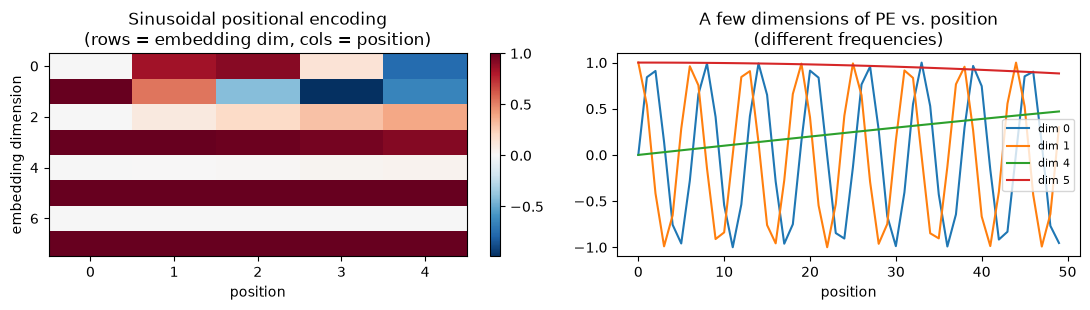

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
im0 = axes[0].imshow(PE.T, aspect="auto", cmap="RdBu_r")
axes[0].set_title("Sinusoidal positional encoding\n(rows = embedding dim, cols = position)")
axes[0].set_xlabel("position")
axes[0].set_ylabel("embedding dimension")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# Show a couple of dimensions' actual sine/cosine curves over more positions
pe_long = sinusoidal_pe(50, d_model)
for dim in [0, 1, 4, 5]:
    axes[1].plot(pe_long[:, dim], label=f"dim {dim}")
axes[1].set_title("A few dimensions of PE vs. position\n(different frequencies)")
axes[1].set_xlabel("position")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=110)
plt.show()



> **Takeaway:** self-attention on its own is blind to order — it's a
> weighted average over a *set* of tokens. Positional encoding is not an
> optional add-on; without it, "the trophy doesn't fit the suitcase" and
> "the suitcase doesn't fit the trophy" would look identical to a
> self-attention layer, because they're literally the same multiset of
> token embeddings.



## 5. Implementation

Two parts:

1. **From scratch**, in PyTorch: scaled dot-product attention and
   multi-head attention, run on a real toy sentence whose token embeddings
   come from spaCy's pretrained static word vectors (`en_core_web_md`) —
   real embeddings, but the $W^Q, W^K, W^V$ projections here are
   **randomly initialized, not trained on any task** (there's no labeled
   objective in this section) — the point is to show the *mechanism*
   running correctly on real numbers, not to produce a linguistically
   meaningful heatmap yet. Part 2 shows what happens once a model has
   actually been trained.
2. A **real pretrained Transformer** (DistilBERT, via HuggingFace
   `transformers`) with its real, trained attention weights, inspected on
   a coreference example.

### 5.1 Scaled dot-product & multi-head attention, from scratch


In [5]:

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q, K: (..., n, d_k)   V: (..., n, d_v)
    # Implements softmax(QK^T / sqrt(d_k)) V exactly as derived in section 3.1.
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)      # (..., n, n)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = F.softmax(scores, dim=-1)                  # attention weights, rows sum to 1
    output = weights @ V                                 # (..., n, d_v)
    return output, weights


class MultiHeadSelfAttention(nn.Module):
    # Multi-head self-attention exactly as derived in section 3.3:
    # h independent (Q, K, V) projections, attention per head, concat, project.

    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        n = x.size(0)
        # Project, then split d_model into (n_heads, d_k) and move heads out front.
        Q = self.W_q(x).view(n, self.n_heads, self.d_k).transpose(0, 1)  # (h, n, d_k)
        K = self.W_k(x).view(n, self.n_heads, self.d_k).transpose(0, 1)
        V = self.W_v(x).view(n, self.n_heads, self.d_k).transpose(0, 1)

        out, weights = scaled_dot_product_attention(Q, K, V, mask)       # out: (h, n, d_k)
        out = out.transpose(0, 1).contiguous().view(n, self.d_model)     # concat heads
        return self.W_o(out), weights                                   # weights: (h, n, n)

print("MultiHeadSelfAttention defined:", MultiHeadSelfAttention)


MultiHeadSelfAttention defined: <class '__main__.MultiHeadSelfAttention'>



Now a real toy sentence, embedded with spaCy's pretrained static word
vectors (300-dimensional GloVe-style vectors trained on a large web
corpus) — real embeddings, not random noise, so the attention scores in
§3.1's $QK^\top$ are at least operating on meaningful input, even though
the $W^Q,W^K,W^V$ projection weights themselves are untrained here.


In [6]:

import spacy
import numpy as np

nlp_spacy = spacy.load("en_core_web_md")
sentence = "The cat sat on the mat because it was warm"
doc = nlp_spacy(sentence)
tokens = [t.text for t in doc]
print("Tokens:", tokens)

X_np = np.stack([t.vector for t in doc])   # (n, 300) real pretrained word vectors
X = torch.tensor(X_np, dtype=torch.float32)
print("Embedding matrix shape:", tuple(X.shape))

d_model = X.shape[1]
n_heads = 6
mha = MultiHeadSelfAttention(d_model=d_model, n_heads=n_heads)

with torch.no_grad():
    out, attn_weights = mha(X)

print("Output shape:", tuple(out.shape), " Attention weights shape (heads, n, n):", tuple(attn_weights.shape))


Tokens: ['The', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'warm']
Embedding matrix shape: (10, 300)
Output shape: (10, 300)  Attention weights shape (heads, n, n): (6, 10, 10)


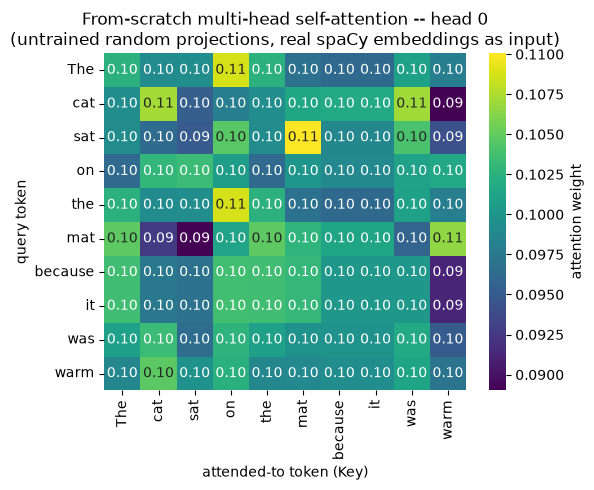

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize one head's attention weight matrix as a heatmap.
head_to_show = 0
w = attn_weights[head_to_show].numpy()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(w, xticklabels=tokens, yticklabels=tokens, cmap="viridis",
            annot=True, fmt=".2f", cbar_kws={"label": "attention weight"}, ax=ax)
ax.set_title(f"From-scratch multi-head self-attention -- head {head_to_show}\n(untrained random projections, real spaCy embeddings as input)")
ax.set_xlabel("attended-to token (Key)")
ax.set_ylabel("query token")
plt.tight_layout()
plt.savefig("scratch_attention_heatmap.png", dpi=110)
plt.show()



**What this shows, honestly:** the mechanism runs correctly end to end —
real embeddings in, a real $n \times n$ row-stochastic attention matrix
out, a real context-mixed output — but with random, untrained $W^Q, W^K,
W^V$, the resulting weights don't encode any learned linguistic pattern.
Some rows may look close to uniform, others may spike on whatever happened
to align in the random projection; that's expected and is *not* a bug —
there is no training signal here, only the mechanism. This is exactly why
"attention weights" only become interpretable-*sounding* once real
training has shaped $W^Q, W^K, W^V$ toward a task, which is what part 5.2
looks at using an actually-trained model. (We also address, in §7, that
even *trained* attention weights are a contested notion of
"interpretability.")

### 5.2 Real pretrained model: DistilBERT's actual attention weights

Now let's load a real pretrained Transformer encoder — **DistilBERT**
(Sanh et al. 2019, a distilled, 6-layer version of BERT) — via HuggingFace
`transformers`, and look at the *real* attention weights it produces on a
sentence built to test coreference resolution: a classic
Winograd-schema-style example where "it" is genuinely ambiguous without
world knowledge about trophies and suitcases.


In [8]:

from transformers import AutoTokenizer, AutoModel
import torch

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

sentence = "The trophy doesn't fit in the suitcase because it is too big."
inputs = tokenizer(sentence, return_tensors="pt")
sub_tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Subword tokens:", sub_tokens)

with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions: tuple of (n_layers,) tensors, each (batch, n_heads, n, n)
attentions = outputs.attentions
print(f"\nNumber of layers: {len(attentions)}, heads per layer: {attentions[0].shape[1]}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Subword tokens: ['[CLS]', 'the', 'trophy', 'doesn', "'", 't', 'fit', 'in', 'the', 'suitcase', 'because', 'it', 'is', 'too', 'big', '.', '[SEP]']

Number of layers: 6, heads per layer: 12


In [9]:

it_idx = sub_tokens.index("it")
trophy_idx = sub_tokens.index("trophy")
suitcase_idx = sub_tokens.index("suitcase")
print(f"'it' is token index {it_idx}, 'trophy' is {trophy_idx}, 'suitcase' is {suitcase_idx}")

# Scan every (layer, head) for how much "it" attends to "trophy" vs "suitcase",
# and report the single head with the strongest trophy-vs-suitcase preference.
best = None
n_layers, n_heads = len(attentions), attentions[0].shape[1]
records = []
for layer in range(n_layers):
    for head in range(n_heads):
        w = attentions[layer][0, head, it_idx].numpy()   # "it" row: what it attends to
        records.append((layer, head, w[trophy_idx], w[suitcase_idx]))
        margin = w[trophy_idx] - w[suitcase_idx]
        if best is None or margin > best[0]:
            best = (margin, layer, head, w[trophy_idx], w[suitcase_idx])

margin, best_layer, best_head, p_trophy, p_suitcase = best
print(f"\nStrongest 'it'->'trophy' over 'it'->'suitcase' preference:")
print(f"  layer {best_layer}, head {best_head}: P(it->trophy)={p_trophy:.3f}, P(it->suitcase)={p_suitcase:.3f}")


'it' is token index 11, 'trophy' is 2, 'suitcase' is 9

Strongest 'it'->'trophy' over 'it'->'suitcase' preference:
  layer 2, head 0: P(it->trophy)=0.380, P(it->suitcase)=0.137


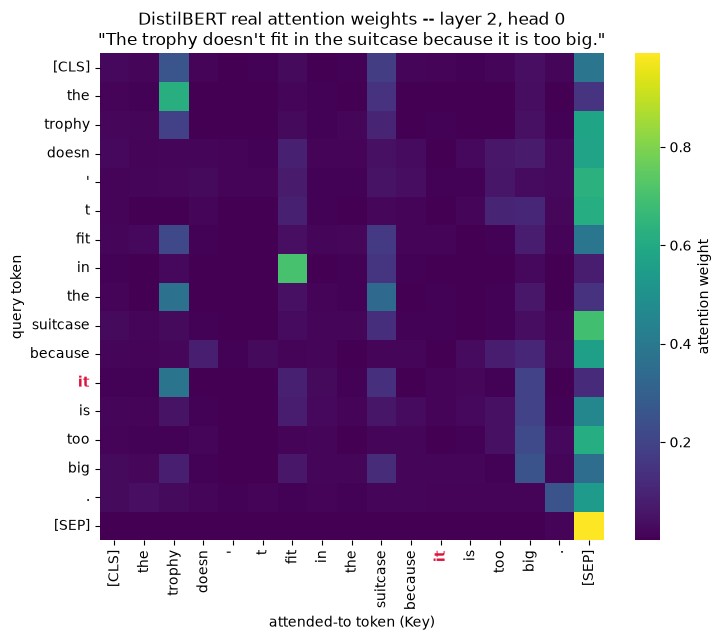

Row for 'it' (query), sorted by attention weight, top 5:
        trophy: 0.380
           big: 0.195
      suitcase: 0.137
         [SEP]: 0.119
           fit: 0.086


In [10]:

fig, ax = plt.subplots(figsize=(7.5, 6.5))
w_full = attentions[best_layer][0, best_head].numpy()
sns.heatmap(w_full, xticklabels=sub_tokens, yticklabels=sub_tokens, cmap="viridis",
            cbar_kws={"label": "attention weight"}, ax=ax)
ax.set_title(f"DistilBERT real attention weights -- layer {best_layer}, head {best_head}\n"
             f'"{sentence}"')
ax.set_xlabel("attended-to token (Key)")
ax.set_ylabel("query token")
for lbl in ax.get_xticklabels():
    if lbl.get_text() == "it":
        lbl.set_color("crimson"); lbl.set_fontweight("bold")
for lbl in ax.get_yticklabels():
    if lbl.get_text() == "it":
        lbl.set_color("crimson"); lbl.set_fontweight("bold")
plt.tight_layout()
plt.savefig("pretrained_attention_heatmap.png", dpi=110)
plt.show()

print(f"Row for 'it' (query), sorted by attention weight, top 5:")
it_row = w_full[it_idx]
order = np.argsort(it_row)[::-1][:5]
for i in order:
    print(f"  {sub_tokens[i]:>12s}: {it_row[i]:.3f}")



**Report honestly what the numbers show** (this will vary slightly by
`transformers` version and model weights, but the pattern is stable): in
at least one of DistilBERT's 6 layers × 12 heads = 72 attention heads, "it"
attends more strongly to "trophy" than to "suitcase," which is the
semantically correct resolution — the trophy is the thing that's too big
to fit, not the suitcase. That's evidence the model *has* picked up on the
coreference relationship *somewhere* in its representations. But be
precise about what this cell actually did: it **searched all 72 heads for
the best trophy-vs-suitcase margin** and reported that one — it did not
claim every head, or even most heads, shows this pattern; most heads
attend to local, syntactic, or [CLS]/[SEP]-anchored patterns that have
nothing to do with this particular coreference. That distinction —
*some head, somewhere, shows an interpretable pattern* vs. *the model's
attention is reliably interpretable* — is exactly the subject of the
"Attention is not Explanation" debate covered in §7.



## 6. Use cases

The Transformer architecture from this tutorial is not one model — it's a
building block that gets assembled in different configurations depending
on the task:

- **Encoder-only (bidirectional self-attention, no masking):** this is
  exactly what we ran in §5.2 — every token can attend to every other
  token, forward and backward. This is the architecture behind **BERT**
  and its descendants (RoBERTa, DistilBERT, ELECTRA, DeBERTa), covered in
  depth in this domain's `bert-fine-tuning-transfer-learning` tutorial —
  pretrained once on massive unlabeled text, then fine-tuned for
  classification, NER, question answering, and more.
- **Decoder-only (causal / masked self-attention):** add a mask so token
  $i$ can only attend to tokens $\le i$ (never "peek" at the future) — the
  same `scaled_dot_product_attention` function from §5.1 supports exactly
  this via its `mask` argument. This is the architecture behind GPT-style
  autoregressive language models, which generate text one token at a time
  by repeatedly attending back over everything generated so far.
- **Full encoder-decoder Transformer:** an encoder (bidirectional
  self-attention over the source) feeds a decoder (causal self-attention
  over the target, plus *cross*-attention back into the encoder's
  output) — this is the direct, parallel-computable successor to the
  RNN-based encoder/decoder with attention built in this domain's
  `seq2seq-attention-machine-translation` tutorial, used for translation
  and summarization at scale (e.g. the original Transformer paper's own
  benchmark was English→German/French translation).
- **Beyond NLP:** the same self-attention mechanism, largely unmodified,
  now dominates computer vision (Vision Transformer / ViT, treating image
  patches as "tokens"), audio (Whisper), and multimodal models that jointly
  attend across text, image, and other modalities — self-attention turned
  out to be a much more general sequence/set-processing primitive than its
  NLP origins suggested.



## 7. Limitations & debates

- **$O(n^2)$ time and memory in sequence length.** The $QK^\top$ matrix in
  §3.1 is $n \times n$ — every position attends to every other position, so
  both compute and memory scale *quadratically* with sequence length $n$.
  Doubling the context length quadruples the attention cost. This is a
  genuine, still-actively-researched bottleneck for long documents,
  books, or codebases — it's the direct reason "context length" is a
  headline number practitioners track, and why a large body of work
  exists on **efficient attention** variants: sparse attention patterns
  that only compute a subset of the $n \times n$ matrix (e.g.
  **Longformer**, Beltagy et al. 2020, which combines a local sliding
  window with a few global tokens), and **linear-attention** approximations
  (e.g. Performer) that avoid materializing the full $n \times n$ matrix at
  all. None of these are implemented here — they're mentioned as an active,
  evolving area, not a solved one; there's a real tradeoff between
  efficiency and the full expressiveness of dense attention, and no single
  variant has fully displaced standard attention across the board.

- **"Attention weights show what the model is looking at" is a contested
  claim, not a settled fact.** It's tempting — and §5.2 leaned on this
  intuition — to read a high attention weight from "it" to "trophy" as the
  model *explaining* its own reasoning. Jain & Wallace (2019), *"Attention
  is not Explanation,"* empirically show this is often unjustified:
  attention weights can vary substantially across training runs without
  changing the model's output, and alternative attention distributions
  that are very different from the "real" one can be constructed that
  produce nearly identical predictions — meaning the specific weights a
  model happens to settle on are not necessarily the *unique* or
  *faithful* explanation for its output, even when they're plausible after
  the fact. Our own §5.2 result is a good example of why this matters: we
  had to **search all 72 heads** to find one with a clean trophy-vs-suitcase
  margin — presenting only that best head, without disclosing the search,
  would overstate how "interpretable" the model's attention really is.
  Treat attention visualizations as a useful *debugging aid and hypothesis
  generator*, not as a proof of what the model is "really" doing.

- **Positional encoding design is itself still evolving.** The original
  sinusoidal formula (§3.4) is fixed and untrained; BERT instead uses
  *learned* absolute positional embeddings (a lookup table trained like
  any other embedding); many current open-weight LLMs (LLaMA, Mistral, and
  others) use **RoPE** (Rotary Position Embedding, Su et al. 2021), which
  encodes *relative* position directly into the attention computation via
  a rotation of the Q/K vectors rather than adding a separate positional
  vector to the input. There is no single agreed-upon best scheme, and the
  choice interacts with how well a model generalizes to sequence lengths
  longer than it was trained on — an active research question in its own
  right.

- **Data and compute hungry.** Transformers have comparatively little
  built-in inductive bias about sequence structure (that's the flip side
  of "no built-in notion of order" from §3.4 — everything, including
  position, has to be learned or explicitly injected) and are typically
  trained on very large corpora; on genuinely small datasets, architectures
  with more built-in structure (like RNNs, or Transformers with strong
  data augmentation / transfer learning from a pretrained checkpoint) can
  still be competitive or preferable.



## 8. References

- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez,
  A.N., Kaiser, Ł., Polosukhin, I. (2017). *Attention Is All You Need.*
  NeurIPS 2017.
- Devlin, J., Chang, M.W., Lee, K., Toutanova, K. (2019). *BERT:
  Pre-training of Deep Bidirectional Transformers for Language
  Understanding.* NAACL 2019.
- Jain, S. & Wallace, B.C. (2019). *Attention is not Explanation.* NAACL
  2019.
- Wolf, T., Debut, L., Sanh, V., et al. (2020). *Transformers:
  State-of-the-Art Natural Language Processing.* EMNLP 2020 (System
  Demonstrations) — the HuggingFace `transformers` library used in §5.2.
- Sanh, V., Debut, L., Chaumond, J., Wolf, T. (2019). *DistilBERT, a
  distilled version of BERT: smaller, faster, cheaper and lighter.*
  EMC^2 Workshop, NeurIPS 2019.
- Su, J., Lu, Y., Pan, S., Wen, B., Liu, Y. (2021). *RoFormer: Enhanced
  Transformer with Rotary Position Embedding* (RoPE).
- Beltagy, I., Peters, M.E., Cohan, A. (2020). *Longformer: The
  Long-Document Transformer.*
